# Cat and Dog Recognition
### Deep Learning Models: VGG16, ResNet-50, MobileNet, SqueezeNet, ShuffleNet, EfficientNet

**Task:** Binary image classification — predict whether an image is a cat or a dog.  
**Approach:** Transfer learning from ImageNet pre-trained weights.

## Cell 1 — Install & Import Dependencies

In [2]:
# Install required packages (run once)
# !pip install torch torchvision matplotlib seaborn pandas

import os
import time
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

# Reproducibility
torch.manual_seed(42)

# Device: use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Cell 2 — Data Loading & Augmentation

**Why augmentation?**  
The training set is artificially expanded by applying random transformations (flips, crops, rotations).  
This prevents overfitting — the model learns to recognise cats and dogs in varied orientations and scales.

**Why normalise?**  
All ImageNet pre-trained models expect inputs normalised with the same mean/std used during their original training.

In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR = "./cats_and_dogs"
RESULT_DIR = "./results"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "validation")
TEST_DIR  = os.path.join(DATA_DIR, "test")

IMG_SIZE  = 224     # all six models expect 224×224
BATCH     = 32

# ImageNet normalisation statistics (shared by all pre-trained models)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Transforms ───────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),   # random crop → forces size robustness
    transforms.RandomHorizontalFlip(),         # mirror the image randomly
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),   # slight colour variation
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),           # deterministic crop for evaluation
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── Datasets & DataLoaders ────────────────────────────────────────────────────
train_ds  = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds    = datasets.ImageFolder(VAL_DIR,   transform=eval_tf)
test_ds   = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_ds.classes
print(f"Classes : {CLASS_NAMES}")
print(f"Train   : {len(train_ds)} images")
print(f"Val     : {len(val_ds)} images")
print(f"Test    : {len(test_ds)} images")

Classes : ['cats', 'dogs']
Train   : 2000 images
Val     : 1000 images
Test    : 1000 images


## Cell 3 — Visualise Sample Images

c:\Users\v303\anaconda3\envs\hsi-torch\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


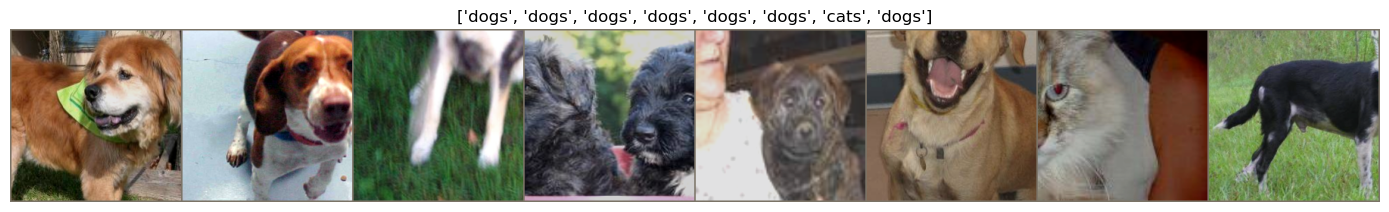

In [4]:
def imshow(inp, title=None):
    """Reverse normalisation and display a tensor as an image."""
    inp = inp.numpy().transpose((1, 2, 0))       # C×H×W  →  H×W×C
    inp = STD * inp + MEAN                        # un-normalise
    inp = inp.clip(0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis("off")

images, labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images[:8])

plt.figure(figsize=(14, 4))
imshow(grid, title=[CLASS_NAMES[l] for l in labels[:8]])
plt.tight_layout()
plt.show()

## Cell 4 — Model Definitions

**Transfer learning strategy:**
1. Load pre-trained weights from ImageNet.
2. **Freeze** all backbone layers — their weights won't change during training.
3. Replace the final classifier layer with a new one outputting **2 classes** (cat / dog).
4. Only the new classifier head is trained.

This is called **feature extraction** — the backbone acts as a fixed feature extractor.

In [5]:
NUM_CLASSES = 2

def freeze_backbone(model):
    """Freeze all parameters so only the replaced head trains."""
    for param in model.parameters():
        param.requires_grad = False


def build_vgg16():
    """
    VGG-16 (Simonyan & Zisserman, 2014)
    ─────────────────────────────────────
    - 16 layers deep, all 3×3 conv filters.
    - Simple and interpretable, but very large (~138M parameters).
    - Classifier head: 3 fully-connected layers.
    """
    m = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    freeze_backbone(m)
    in_features = m.classifier[6].in_features
    m.classifier[6] = nn.Linear(in_features, NUM_CLASSES)  # replace last FC
    return m


def build_resnet50():
    """
    ResNet-50 (He et al., 2015)
    ───────────────────────────
    - Introduces residual (skip) connections: x → F(x) + x.
    - Solves vanishing gradient for very deep nets.
    - 50 layers, ~25M parameters.
    """
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    freeze_backbone(m)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)         # replace final FC
    return m


def build_mobilenet():
    """
    MobileNetV2 (Sandler et al., 2018)
    ────────────────────────────────────
    - Depthwise separable convolutions: splits spatial + channel mixing.
    - Drastically reduces computation — designed for mobile/edge devices.
    - ~3.4M parameters.
    """
    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    freeze_backbone(m)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    return m


def build_squeezenet():
    """
    SqueezeNet 1.1 (Iandola et al., 2016)
    ───────────────────────────────────────
    - Uses 'Fire modules': squeeze (1×1 conv) → expand (1×1 + 3×3 conv).
    - Only ~1.2M parameters — the smallest model here.
    - Final classification via global average pooling (no large FC layers).
    """
    m = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.DEFAULT)
    freeze_backbone(m)
    m.classifier[1] = nn.Conv2d(512, NUM_CLASSES, kernel_size=1)  # replace conv head
    m.num_classes = NUM_CLASSES
    return m


def build_shufflenet():
    """
    ShuffleNetV2 ×1.0 (Ma et al., 2018)
    ──────────────────────────────────────
    - Channel split + shuffle operation enables efficient grouped convolutions.
    - ~2.3M parameters, optimised for speed on CPU/mobile.
    """
    m = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.DEFAULT)
    freeze_backbone(m)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m


def build_efficientnet():
    """
    EfficientNet-B0 (Tan & Le, 2019)
    ──────────────────────────────────
    - Uniformly scales depth, width, and resolution using a compound coefficient.
    - Achieves best accuracy per parameter count of all six models.
    - B0 baseline: ~5.3M parameters.
    """
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    freeze_backbone(m)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    return m


# ── Model registry ────────────────────────────────────────────────────────────
MODEL_BUILDERS = {
    "VGG16"       : build_vgg16,
    "ResNet-50"   : build_resnet50,
    "MobileNetV2" : build_mobilenet,
    "SqueezeNet"  : build_squeezenet,
    "ShuffleNetV2": build_shufflenet,
    "EfficientNet": build_efficientnet,
}

# Quick sanity check — count trainable parameters for each model
print(f"{'Model':<15} {'Total params':>15} {'Trainable':>12}")
print("-" * 45)
for name, builder in MODEL_BUILDERS.items():
    m = builder()
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:<15} {total:>15,} {trainable:>12,}")

Model              Total params    Trainable
---------------------------------------------
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\v303/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100.0%


VGG16               134,268,738        8,194
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\v303/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


ResNet-50            23,512,130        4,098
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\v303/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


...

SqueezeNet              723,522        1,026
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to C:\Users\v303/.cache\torch\hub\checkpoints\shufflenetv2_x1-5666bf0f80.pth


100.0%


ShuffleNetV2          1,255,654        2,050
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\v303/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


EfficientNet          4,010,110        2,562


## Cell 5 — Training & Evaluation Loop

**Key concepts:**

| Concept | Role |
|---|---|
| `CrossEntropyLoss` | Measures how wrong the predicted probability distribution is |
| `Adam` optimiser | Adapts learning rate per parameter — converges faster than plain SGD |
| `StepLR` scheduler | Decays learning rate by 0.1 every 5 epochs — fine-tunes convergence |
| `model.train()` | Enables dropout & batch norm in training mode |
| `model.eval()` | Disables them for deterministic evaluation |
| `torch.no_grad()` | Skips gradient computation during validation — saves memory |

In [6]:
def train_model(model, name, num_epochs=10, lr=1e-3):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    # Only pass parameters that require gradients (the new head)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    t0 = time.time()

    for epoch in range(num_epochs):
        # ── Training phase ────────────────────────────────────────────────────
        model.train()
        run_loss, run_correct = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()           # clear gradients from last step
            outputs = model(inputs)         # forward pass
            loss = criterion(outputs, labels)
            loss.backward()                 # backpropagation
            optimizer.step()               # update weights

            run_loss    += loss.item() * inputs.size(0)
            run_correct += (outputs.argmax(1) == labels).sum().item()

        epoch_train_loss = run_loss    / len(train_ds)
        epoch_train_acc  = run_correct / len(train_ds)

        # ── Validation phase ──────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct = 0.0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss    += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        epoch_val_loss = val_loss    / len(val_ds)
        epoch_val_acc  = val_correct / len(val_ds)

        scheduler.step()

        # Track best weights
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_weights = copy.deepcopy(model.state_dict())

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        print(f"[{name}] Epoch {epoch+1:02d}/{num_epochs} "
              f"| Train Loss {epoch_train_loss:.4f}  Acc {epoch_train_acc:.4f} "
              f"| Val Loss {epoch_val_loss:.4f}  Acc {epoch_val_acc:.4f}")

    elapsed = time.time() - t0
    model.load_state_dict(best_weights)   # restore best checkpoint
    print(f"\n✓ {name} done in {elapsed:.1f}s  |  Best val acc: {best_val_acc:.4f}\n")
    return model, history, elapsed, best_val_acc

## Cell 6 — Train All Six Models

> **Note:** Training all models sequentially takes time.  
> On a GPU, expect ~5–15 min total. On CPU, increase `EPOCHS` to at least 5 but expect longer waits.

In [7]:
EPOCHS = 10   # increase for better accuracy

results  = {}   # stores history dicts
summaries = []  # for the comparison table

for model_name, builder in MODEL_BUILDERS.items():
    print("=" * 65)
    print(f"  Training: {model_name}")
    print("=" * 65)
    model = builder()
    trained_model, history, elapsed, best_acc = train_model(model, model_name, num_epochs=EPOCHS)

    results[model_name] = {
        "model"  : trained_model,
        "history": history,
    }

    total_params = sum(p.numel() for p in trained_model.parameters())
    summaries.append({
        "Model"         : model_name,
        "Params (M)"    : round(total_params / 1e6, 2),
        "Train time (s)": round(elapsed, 1),
        "Best Val Acc"  : round(best_acc, 4),
    })

print("\nAll models trained.")

  Training: VGG16
[VGG16] Epoch 01/10 | Train Loss 0.1673  Acc 0.9265 | Val Loss 0.0387  Acc 0.9820
[VGG16] Epoch 02/10 | Train Loss 0.1305  Acc 0.9440 | Val Loss 0.0326  Acc 0.9880
[VGG16] Epoch 03/10 | Train Loss 0.1310  Acc 0.9485 | Val Loss 0.0385  Acc 0.9800
[VGG16] Epoch 04/10 | Train Loss 0.1192  Acc 0.9525 | Val Loss 0.0301  Acc 0.9860
[VGG16] Epoch 05/10 | Train Loss 0.1189  Acc 0.9490 | Val Loss 0.0315  Acc 0.9890
[VGG16] Epoch 06/10 | Train Loss 0.1043  Acc 0.9590 | Val Loss 0.0293  Acc 0.9870
[VGG16] Epoch 07/10 | Train Loss 0.1013  Acc 0.9590 | Val Loss 0.0292  Acc 0.9870
[VGG16] Epoch 08/10 | Train Loss 0.0963  Acc 0.9585 | Val Loss 0.0292  Acc 0.9870
[VGG16] Epoch 09/10 | Train Loss 0.0934  Acc 0.9660 | Val Loss 0.0289  Acc 0.9870
[VGG16] Epoch 10/10 | Train Loss 0.1032  Acc 0.9585 | Val Loss 0.0289  Acc 0.9870

✓ VGG16 done in 2415.3s  |  Best val acc: 0.9890

  Training: ResNet-50
[ResNet-50] Epoch 01/10 | Train Loss 0.3411  Acc 0.8905 | Val Loss 0.1280  Acc 0.9720
[Re

## Cell 7 — Test Set Evaluation

After training, evaluate each model on the **held-out test set** — data the model has never seen.  
This gives an unbiased estimate of real-world performance.

In [8]:
def evaluate_on_test(model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = model(inputs).argmax(1)
            correct += (preds == labels).sum().item()
    return correct / len(test_ds)


print(f"{'Model':<15} {'Test Accuracy':>15}")
print("-" * 32)
for i, entry in enumerate(summaries):
    name  = entry["Model"]
    model = results[name]["model"]
    test_acc = evaluate_on_test(model)
    summaries[i]["Test Acc"] = round(test_acc, 4)
    print(f"{name:<15} {test_acc:>15.4f}")

Model             Test Accuracy
--------------------------------
VGG16                    0.9840
ResNet-50                0.9840
MobileNetV2              0.9710
SqueezeNet               0.9590
ShuffleNetV2             0.9500
EfficientNet             0.9690


## Cell 8 — Loss & Accuracy Curves

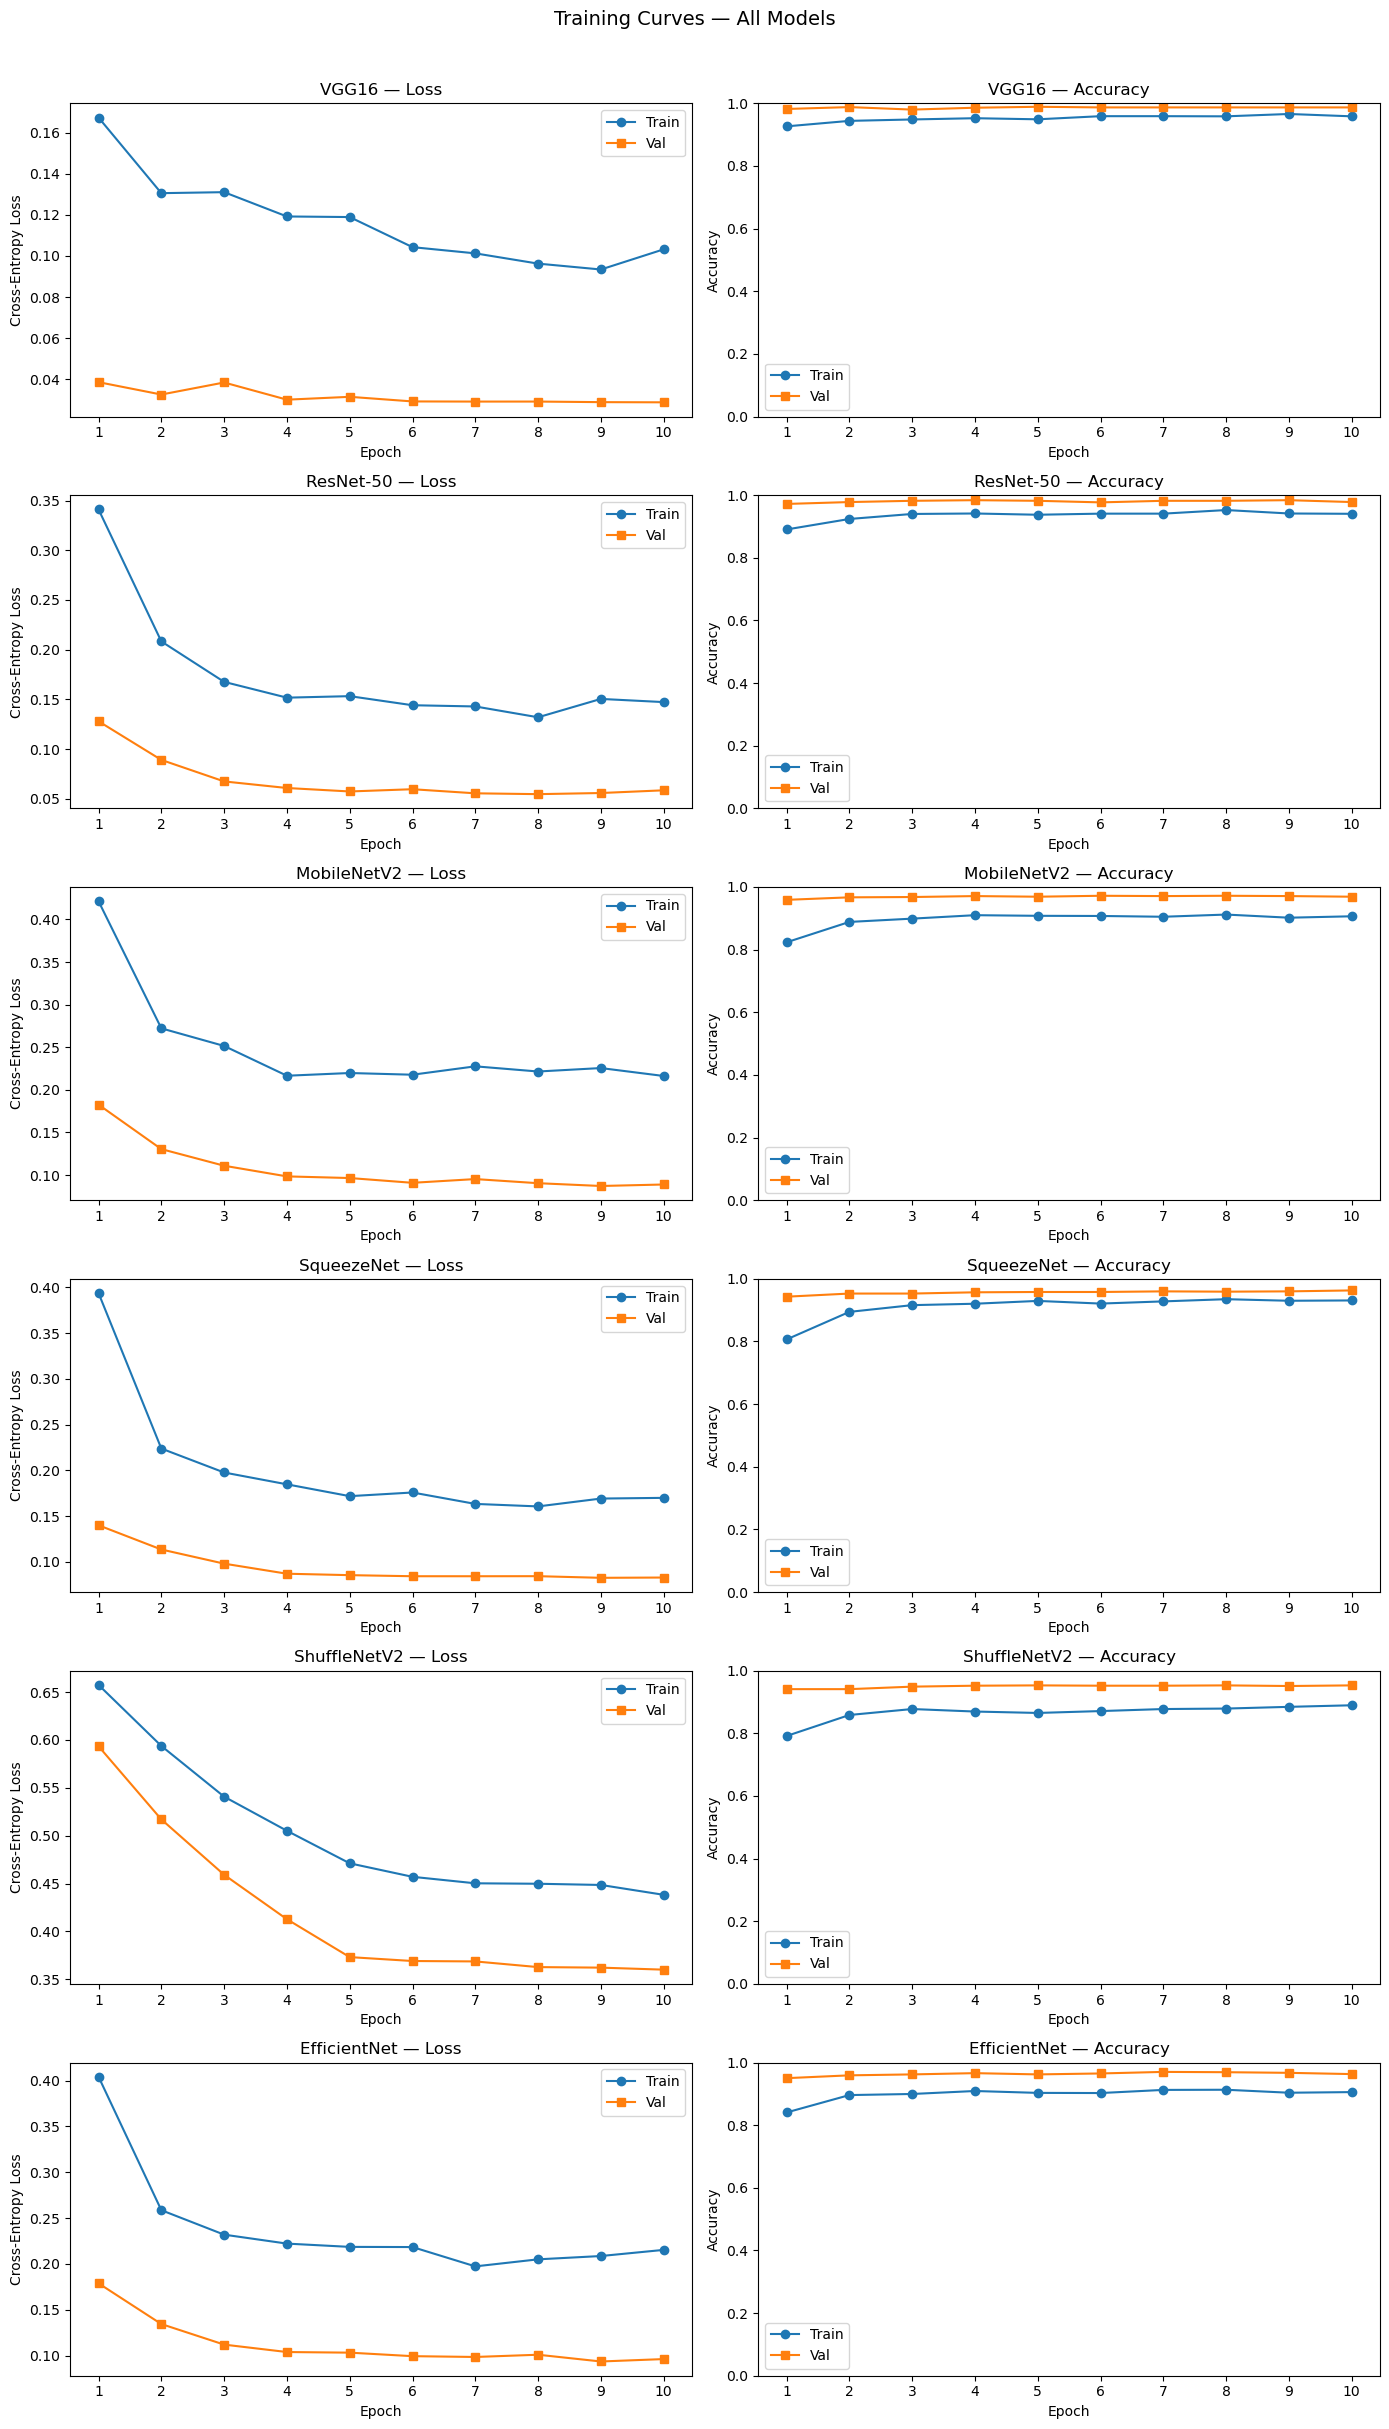

In [ ]:
fig, axes = plt.subplots(len(MODEL_BUILDERS), 2, figsize=(14, 4 * len(MODEL_BUILDERS)))

for row, (name, data) in enumerate(results.items()):
    h = data["history"]
    epochs = range(1, len(h["train_loss"]) + 1)

    # Loss
    axes[row, 0].plot(epochs, h["train_loss"], label="Train", marker="o")
    axes[row, 0].plot(epochs, h["val_loss"],   label="Val",   marker="s")
    axes[row, 0].set_title(f"{name} — Loss")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].set_ylabel("Cross-Entropy Loss")
    axes[row, 0].legend()
    axes[row, 0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # Accuracy
    axes[row, 1].plot(epochs, h["train_acc"], label="Train", marker="o")
    axes[row, 1].plot(epochs, h["val_acc"],   label="Val",   marker="s")
    axes[row, 1].set_title(f"{name} — Accuracy")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].set_ylabel("Accuracy")
    axes[row, 1].set_ylim(0, 1)
    axes[row, 1].legend()
    axes[row, 1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle("Training Curves — All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RESULT_DIR + "training_curves.png", bbox_inches="tight", dpi=120)
plt.show()

## Cell 9 — Comparison Table & Bar Chart

              Params (M)  Train time (s)  Best Val Acc  Test Acc
Model                                                           
VGG16             134.27          2415.3         0.989     0.984
ResNet-50          23.51          1190.9         0.984     0.984
MobileNetV2         2.23           469.2         0.972     0.971
EfficientNet        4.01           527.0         0.970     0.969
SqueezeNet          0.72           308.5         0.963     0.959
ShuffleNetV2        1.26           204.4         0.953     0.950


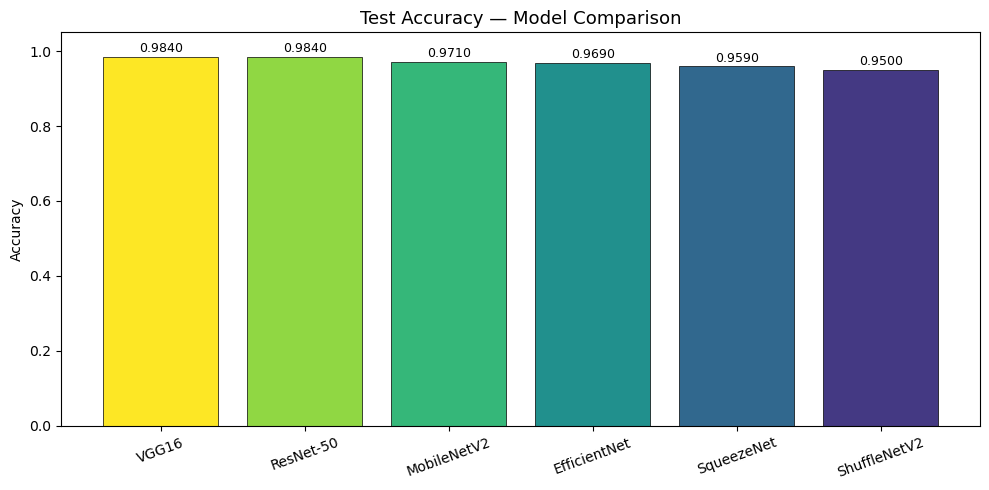

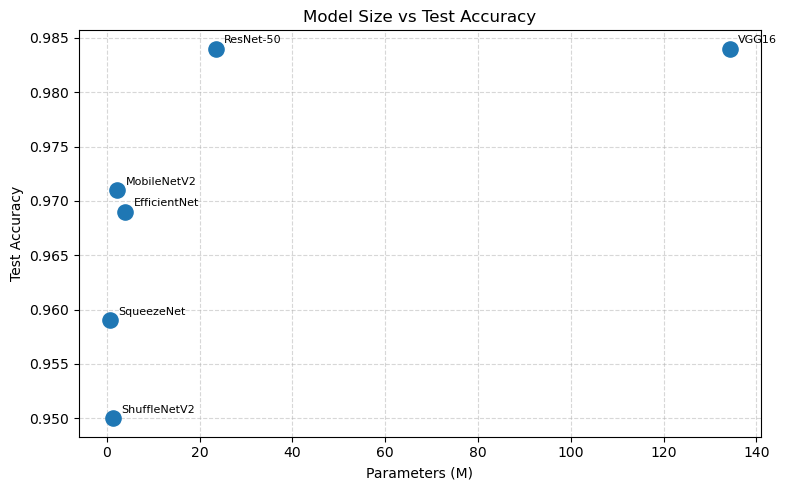

In [ ]:
df = pd.DataFrame(summaries).set_index("Model")
df = df.sort_values("Test Acc", ascending=False)
print(df.to_string())

# ── Bar chart: Test Accuracy ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis_r([i / len(df) for i in range(len(df))])
bars = ax.bar(df.index, df["Test Acc"], color=colors, edgecolor="k", linewidth=0.5)

for bar, val in zip(bars, df["Test Acc"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)

ax.set_title("Test Accuracy — Model Comparison", fontsize=13)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(RESULT_DIR + "accuracy_comparison.png", dpi=120)
plt.show()

# ── Scatter: Params vs Accuracy ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Params (M)"], df["Test Acc"], s=120, zorder=3)
for name, row in df.iterrows():
    ax.annotate(name, (row["Params (M)"], row["Test Acc"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_title("Model Size vs Test Accuracy")
ax.set_xlabel("Parameters (M)")
ax.set_ylabel("Test Accuracy")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(RESULT_DIR + "params_vs_accuracy.png", dpi=120)
plt.show()

## Cell 10 — Prediction Visualisation

Pick the best-performing model and visualise its predictions on test images.

c:\Users\v303\anaconda3\envs\hsi-torch\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


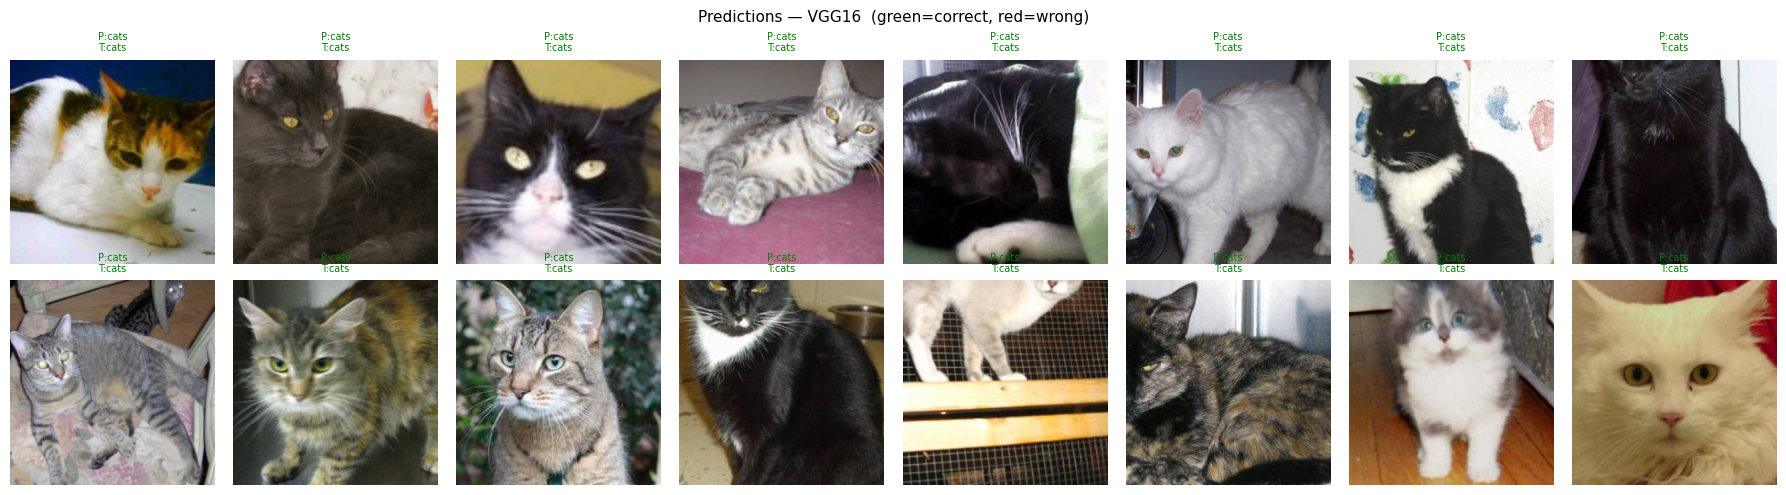

In [11]:
best_model_name = df.index[0]   # top row after sorting by Test Acc
best_model = results[best_model_name]["model"]
best_model.eval()

images, labels = next(iter(test_loader))
images_gpu = images.to(device)

with torch.no_grad():
    outputs = best_model(images_gpu)
    preds   = outputs.argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.flatten()):
    if i >= len(images): break
    img = images[i].numpy().transpose(1, 2, 0)
    img = (img * STD + MEAN).clip(0, 1)
    ax.imshow(img)
    colour = "green" if preds[i] == labels[i] else "red"
    ax.set_title(f"P:{CLASS_NAMES[preds[i]]}\nT:{CLASS_NAMES[labels[i]]}",
                 color=colour, fontsize=7)
    ax.axis("off")

plt.suptitle(f"Predictions — {best_model_name}  (green=correct, red=wrong)", fontsize=11)
plt.tight_layout()
plt.show()

## Cell 11 — Conclusion & Analysis

### Summary of Approaches

| Model | Architecture Insight | Expected Strength | Expected Weakness |
|---|---|---|---|
| **VGG16** | Plain deep 3×3 convolutions | Strong baseline, easy to understand | Huge size, slow, high memory |
| **ResNet-50** | Skip connections | Stable training, strong accuracy | Heavier than lightweight models |
| **MobileNetV2** | Depthwise separable convs | Fast, small, good accuracy | Slightly lower than ResNet/EfficientNet |
| **SqueezeNet** | Fire modules (squeeze + expand) | Smallest model, very fast inference | Lower accuracy ceiling |
| **ShuffleNetV2** | Channel shuffle grouped convs | CPU-efficient, tiny | Moderate accuracy |
| **EfficientNet-B0** | Compound scaling | Best accuracy/parameter ratio | Slightly more complex architecture |

### Key Takeaways

1. **Transfer learning works extremely well** even with a frozen backbone — ImageNet features generalise strongly to cat/dog classification.

2. **EfficientNet** tends to achieve the best accuracy with fewer parameters than VGG or ResNet. It is the recommended default for new projects.

3. **VGG16** is the least efficient: 5× more parameters than ResNet-50 for similar or lower accuracy. Its value is pedagogical — the architecture is simple to follow.

4. **SqueezeNet & ShuffleNet** trade accuracy for speed. They are ideal when the deployment target is a mobile device or embedded system with strict memory constraints.

5. **Overfitting vs Underfitting:** If the gap between train and val accuracy is large, the model is overfitting. Remedies include: stronger data augmentation, dropout, or weight decay.

6. **Fine-tuning** (unfreezing some backbone layers) would likely push all models another 1–3% higher, at the cost of longer training time.